In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [53]:
PARQUET_PATH = r"D:\MY_PROJECT\citibike_weather_2024.parquet"
con = duckdb.connect()


### FILE SIZE

In [9]:
import os

size_gb = os.path.getsize(PARQUET_PATH) / (1024**3)
print(f"Parquet file size: {size_gb:.2f} GB")


Parquet file size: 2.46 GB


### NO. OF ROWS/ COLUMNS AND DESCRIPTION

In [10]:
con.execute(f"""
SELECT 
    COUNT(*) AS total_rows
FROM '{PARQUET_PATH}'
""").fetchdf()


,total_rows
0,44303209


In [11]:
import pyarrow.parquet as pq
pf = pq.ParquetFile(PARQUET_PATH)

print("Number of Row Groups :", pf.metadata.num_row_groups)

total_rows = 0
for i in range(pf.metadata.num_row_groups):
    total_rows += pf.metadata.row_group(i).num_rows

print("Total Rows :", total_rows)
print("Total Columns :", pf.metadata.num_columns)

Number of Row Groups : 48
Total Rows : 44303209
Total Columns : 41


In [12]:
duckdb.sql(f"SELECT * FROM '{PARQUET_PATH}' LIMIT 10;")

┌──────────────────┬───────────────┬─────────────────────────┬─────────────────────────┬─────────────────────────────┬──────────────────┬──────────────────────────────┬────────────────┬─────────────┬──────────────┬────────────────────┬────────────────────┬───────────────┬────────────┬───────────────┬──────────┬───────────┬───────────┬─────────────────────────────┬─────────┬─────────────────┬─────────┬─────────────────┬─────────┬────────────────┬─────────┬────────────────┬─────────┬──────────────────┬─────────┬─────────────────┬─────────┬─────────┬─────────┬────────────────┬─────────┬────────────────┬─────────┬─────────────────┬─────────┬──────────┐
│     ride_id      │ rideable_type │       started_at        │        ended_at         │     start_station_name      │ start_station_id │       end_station_name       │ end_station_id │  start_lat  │  start_lng   │      end_lat       │      end_lng       │ member_casual │ trip_date  │    STATION    │ LATITUDE │ LONGITUDE │ ELEVATION │       

In [13]:
duckdb.sql(f"SELECT MAX(TEMP), MIN(TEMP) from '{PARQUET_PATH}'")

┌─────────────┬─────────────┐
│ max("TEMP") │ min("TEMP") │
│   varchar   │   varchar   │
├─────────────┼─────────────┤
│ 86.7        │ 18.3        │
└─────────────┴─────────────┘

In [14]:
con.execute(f"""
DESCRIBE SELECT * FROM '{PARQUET_PATH}'
""").fetchdf()


,column_name,column_type,null,key,default,extra
0,ride_id,VARCHAR,YES,None,None,None
1,rideable_type,VARCHAR,YES,None,None,None
2,started_at,VARCHAR,YES,None,None,None
3,ended_at,VARCHAR,YES,None,None,None
4,start_station_name,VARCHAR,YES,None,None,None
5,start_station_id,VARCHAR,YES,None,None,None
6,end_station_name,VARCHAR,YES,None,None,None
7,end_station_id,VARCHAR,YES,None,None,None
8,start_lat,VARCHAR,YES,None,None,None
9,start_lng,VARCHAR,YES,None,None,None


In [15]:
con.execute(f"""
SELECT 
    MIN(started_at) AS min_date,
    MAX(started_at) AS max_date
FROM '{PARQUET_PATH}'
""").fetchdf()


,min_date,max_date
0,2023-12-31 02:36:55.648,2024-12-31 23:57:46.390


In [36]:
con.execute(f"""
SELECT 
    DISTINCT trip_date
FROM '{PARQUET_PATH}' order by trip_date asc
""").fetchdf()


,trip_date
0,2023-12-31
1,2024-01-01
2,2024-01-02
3,2024-01-03
4,2024-01-04
...,...
362,2024-12-27
363,2024-12-28
364,2024-12-29
365,2024-12-30


### NULL VALUES

In [16]:
import pandas as pd

pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # no line wrapping
pd.set_option('display.max_colwidth', None)  # show full column names


In [17]:
con.execute(f"""
SELECT
    COUNT(*) AS total_rows,

    SUM(ride_id IS NULL) AS null_ride_id,
    SUM(rideable_type IS NULL) AS null_rideable_type,
    SUM(started_at IS NULL) AS null_started_at,
    SUM(ended_at IS NULL) AS null_ended_at,

    SUM(start_station_name IS NULL) AS null_start_station_name,
    SUM(start_station_id IS NULL) AS null_start_station_id,
    SUM(end_station_name IS NULL) AS null_end_station_name,
    SUM(end_station_id IS NULL) AS null_end_station_id,

    SUM(start_lat IS NULL) AS null_start_lat,
    SUM(start_lng IS NULL) AS null_start_lng,
    SUM(end_lat IS NULL) AS null_end_lat,
    SUM(end_lng IS NULL) AS null_end_lng,

    SUM(member_casual IS NULL) AS null_member_casual,
    SUM(trip_date IS NULL) AS null_trip_date,

    SUM(STATION IS NULL) AS null_STATION,
    SUM(LATITUDE IS NULL) AS null_LATITUDE,
    SUM(LONGITUDE IS NULL) AS null_LONGITUDE,
    SUM(ELEVATION IS NULL) AS null_ELEVATION,
    SUM(NAME IS NULL) AS null_NAME,

    SUM(TEMP IS NULL) AS null_TEMP,
    SUM(TEMP_ATTRIBUTES IS NULL) AS null_TEMP_ATTRIBUTES,

    SUM(DEWP IS NULL) AS null_DEWP,
    SUM(DEWP_ATTRIBUTES IS NULL) AS null_DEWP_ATTRIBUTES,

    SUM(SLP IS NULL) AS null_SLP,
    SUM(SLP_ATTRIBUTES IS NULL) AS null_SLP_ATTRIBUTES,

    SUM(STP IS NULL) AS null_STP,
    SUM(STP_ATTRIBUTES IS NULL) AS null_STP_ATTRIBUTES,

    SUM(VISIB IS NULL) AS null_VISIB,
    SUM(VISIB_ATTRIBUTES IS NULL) AS null_VISIB_ATTRIBUTES,

    SUM(WDSP IS NULL) AS null_WDSP,
    SUM(WDSP_ATTRIBUTES IS NULL) AS null_WDSP_ATTRIBUTES,

    SUM(MXSPD IS NULL) AS null_MXSPD,
    SUM(GUST IS NULL) AS null_GUST,

    SUM(MAX IS NULL) AS null_MAX,
    SUM(MAX_ATTRIBUTES IS NULL) AS null_MAX_ATTRIBUTES,

    SUM(MIN IS NULL) AS null_MIN,
    SUM(MIN_ATTRIBUTES IS NULL) AS null_MIN_ATTRIBUTES,

    SUM(PRCP IS NULL) AS null_PRCP,
    SUM(PRCP_ATTRIBUTES IS NULL) AS null_PRCP_ATTRIBUTES,

    SUM(SNDP IS NULL) AS null_SNDP,


FROM '{PARQUET_PATH}'
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,null_ride_id,null_rideable_type,null_started_at,null_ended_at,null_start_station_name,null_start_station_id,null_end_station_name,null_end_station_id,null_start_lat,null_start_lng,null_end_lat,null_end_lng,null_member_casual,null_trip_date,null_STATION,null_LATITUDE,null_LONGITUDE,null_ELEVATION,null_NAME,null_TEMP,null_TEMP_ATTRIBUTES,null_DEWP,null_DEWP_ATTRIBUTES,null_SLP,null_SLP_ATTRIBUTES,null_STP,null_STP_ATTRIBUTES,null_VISIB,null_VISIB_ATTRIBUTES,null_WDSP,null_WDSP_ATTRIBUTES,null_MXSPD,null_GUST,null_MAX,null_MAX_ATTRIBUTES,null_MIN,null_MIN_ATTRIBUTES,null_PRCP,null_PRCP_ATTRIBUTES,null_SNDP
0,44303209,0.0,0.0,0.0,0.0,29835.0,29835.0,114545.0,122573.0,29835.0,29835.0,122304.0,122304.0,0.0,0.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0,410.0


### Duplicates

In [18]:
con.execute(f"""
SELECT 
    COUNT(*) - COUNT(DISTINCT ride_id) AS duplicate_rides
FROM '{PARQUET_PATH}'
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_rides
0,0


Invalid durations (negative or zero)

In [19]:
con.execute(f"""
SELECT COUNT(*) AS invalid_duration_rows
FROM '{PARQUET_PATH}'
WHERE ended_at <= started_at
""").fetchdf()


,invalid_duration_rows
0,319


In [20]:
con.execute(f"""
CREATE OR REPLACE VIEW citibike_typed AS
SELECT
    ride_id,
    rideable_type,
    CAST(started_at AS TIMESTAMP) AS started_at,
    CAST(ended_at AS TIMESTAMP) AS ended_at,
    CAST(start_lat AS DOUBLE) AS start_lat,
    CAST(start_lng AS DOUBLE) AS start_lng,
    CAST(end_lat AS DOUBLE) AS end_lat,
    CAST(end_lng AS DOUBLE) AS end_lng,
    CAST(TEMP AS DOUBLE) AS temp,
    CAST(PRCP AS DOUBLE) AS prcp,
    CAST(WDSP AS DOUBLE) AS wdsp,
    member_casual,
    trip_date
FROM '{PARQUET_PATH}'
""")


In [21]:
con.execute("DESCRIBE citibike_typed").fetchdf()


,column_name,column_type,null,key,default,extra
0,ride_id,VARCHAR,YES,None,None,None
1,rideable_type,VARCHAR,YES,None,None,None
2,started_at,TIMESTAMP,YES,None,None,None
3,ended_at,TIMESTAMP,YES,None,None,None
4,start_lat,DOUBLE,YES,None,None,None
5,start_lng,DOUBLE,YES,None,None,None
6,end_lat,DOUBLE,YES,None,None,None
7,end_lng,DOUBLE,YES,None,None,None
8,temp,DOUBLE,YES,None,None,None
9,prcp,DOUBLE,YES,None,None,None


### Trip duration distribution

In [22]:
df_duration = con.execute("""
SELECT
    EXTRACT(EPOCH FROM (ended_at - started_at))/60 AS duration_min
FROM citibike_typed
WHERE ended_at > started_at
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

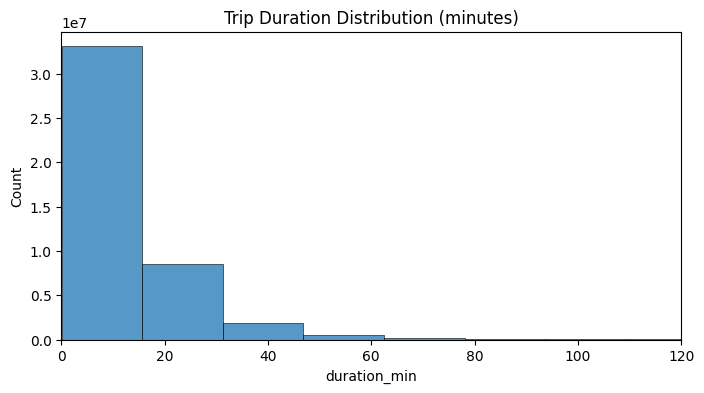

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(df_duration["duration_min"], bins=100)
plt.xlim(0,120)
plt.title("Trip Duration Distribution (minutes)")
plt.show()


### Categorical distribution (member vs casual)

In [24]:
con.execute("""
SELECT
    member_casual,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY member_casual
""").fetchdf()


,member_casual,trips
0,member,35746278
1,casual,8556931


 ## 🔗 PHASE 5 — TIME-BASED ANALYSIS

### Monthly trend

In [25]:
df_month = con.execute("""
SELECT
    strftime('%Y-%m', started_at) AS month,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY month
ORDER BY month
""").fetchdf()


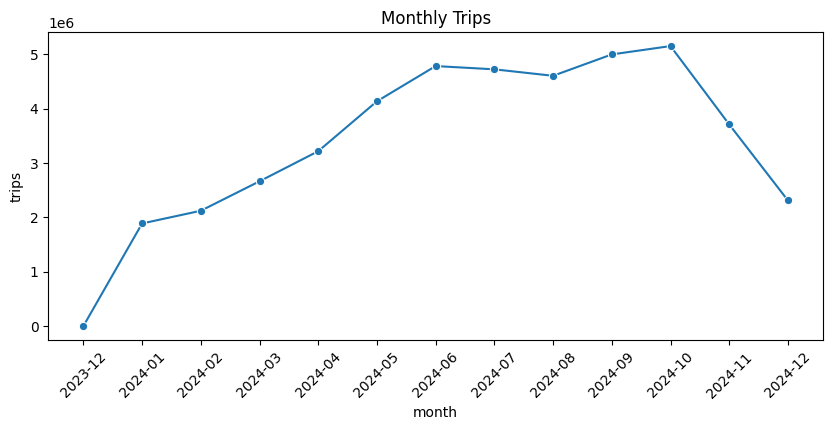

In [26]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_month, x="month", y="trips", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Trips")
plt.show()


### Hourly usage

In [27]:
df_hour = con.execute("""
SELECT
    EXTRACT(HOUR FROM started_at) AS hour,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY hour
ORDER BY hour
""").fetchdf()


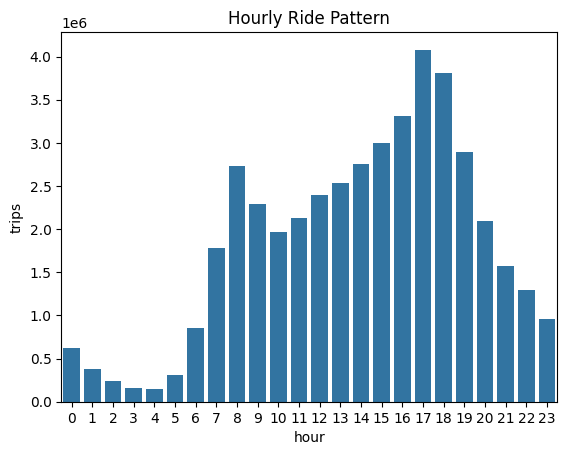

In [28]:
sns.barplot(data=df_hour, x="hour", y="trips")
plt.title("Hourly Ride Pattern")
plt.show()


### Weekday vs Weekend

In [29]:
con.execute("""
SELECT
    CASE 
        WHEN EXTRACT(DOW FROM started_at) IN (0,6) THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY day_type
""").fetchdf()


,day_type,trips
0,Weekend,11563552
1,Weekday,32739657


## WEATHER RELATIONSHIP

### Temperature vs trips

In [37]:
# df_temp = con.execute("""
# SELECT
#     ROUND(temp,1) AS temperature,
#     COUNT(*) AS trips
# FROM citibike_typed
# WHERE temp IS NOT NULL
# GROUP BY temperature
# ORDER BY temperature
# """).fetchdf()

df_temp = con.execute("""
SELECT
    ROUND((temp - 32) * 5.0 / 9.0, 1) AS temperature_c,
    COUNT(*) AS trips
FROM citibike_typed
WHERE temp IS NOT NULL
GROUP BY temperature_c
ORDER BY temperature_c
""").fetchdf()



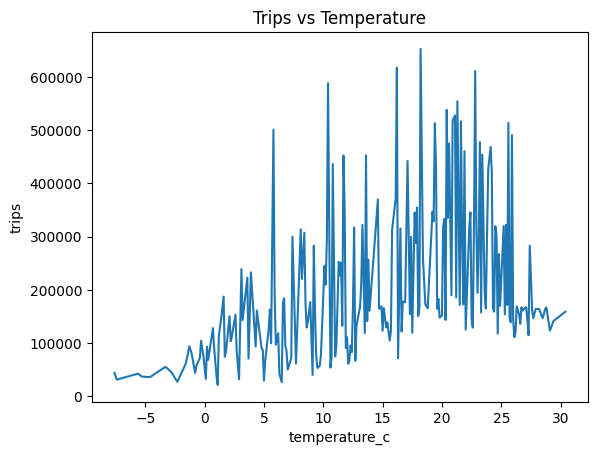

In [39]:
sns.lineplot(data=df_temp, x="temperature_c", y="trips")
plt.title("Trips vs Temperature")
plt.show()


### Rain impact

In [32]:
con.execute("""
SELECT
    CASE WHEN prcp > 0 THEN 'Rainy' ELSE 'No Rain' END AS rain_flag,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY rain_flag
""").fetchdf()


,rain_flag,trips
0,No Rain,29824925
1,Rainy,14478284


## CONSISTENCY CHECK

In [33]:
con.execute("""
SELECT
    strftime('%Y-%m', started_at) AS month,
    COUNT(*) AS rows
FROM citibike_typed
GROUP BY month
ORDER BY month
""").fetchdf()

,month,rows
0,2023-12,410
1,2024-01,1887908
2,2024-02,2121506
3,2024-03,2663416
4,2024-04,3216957
5,2024-05,4135049
6,2024-06,4782935
7,2024-07,4722952
8,2024-08,4603942
9,2024-09,4997288


In [34]:
summary = {
    "Total Rows": con.execute("SELECT COUNT(*) FROM citibike_typed").fetchone()[0],
    "Unique Stations": con.execute("SELECT COUNT(DISTINCT start_lat || start_lng) FROM citibike_typed").fetchone()[0],
    "Duplicate Rides": con.execute("SELECT COUNT(*) - COUNT(DISTINCT ride_id) FROM citibike_typed").fetchone()[0]
}

summary


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

{'Total Rows': 44303209, 'Unique Stations': 2286, 'Duplicate Rides': 0}

## OUTLIER CHECK

#### trip duration (minutes)

In [40]:
df_duration = con.execute("""
SELECT
    EXTRACT(EPOCH FROM (ended_at - started_at)) / 60 AS duration_min
FROM citibike_typed
WHERE ended_at > started_at
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#### Detect unrealistic duration outliers

In [42]:
con.execute("""
SELECT
    COUNT(*) AS outlier_trips
FROM citibike_typed
WHERE EXTRACT(EPOCH FROM (ended_at - started_at)) / 60 > 1440
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,outlier_trips
0,10936


#### Detect impossible temperature values

In [43]:
con.execute("""
SELECT
    MIN((temp - 32) * 5.0 / 9.0) AS min_temp_c,
    MAX((temp - 32) * 5.0 / 9.0) AS max_temp_c
FROM citibike_typed
WHERE temp IS NOT NULL
""").fetchdf()


,min_temp_c,max_temp_c
0,-7.611111,30.388889


#### OUTLIER CHECK — PRECIPITATION

In [44]:
con.execute("""
SELECT COUNT(*) AS prcp_outliers
FROM citibike_typed
WHERE prcp < 0
""").fetchdf()


,prcp_outliers
0,0


#### OUTLIER CHECK — WIND SPEED

In [45]:
con.execute("""
SELECT
    MIN(wdsp) AS min_wind,
    MAX(wdsp) AS max_wind
FROM citibike_typed
WHERE wdsp IS NOT NULL
""").fetchdf()


,min_wind,max_wind
0,0.5,11.0


In [46]:
con.execute("""
SELECT COUNT(*) AS wind_outliers
FROM citibike_typed
WHERE wdsp < 0 OR wdsp > 150
""").fetchdf()


,wind_outliers
0,0


In [56]:
# con.execute("""
# CREATE OR REPLACE VIEW citibike_typed1 AS
# SELECT
#     ride_id,
#     rideable_type,

#     CAST(started_at AS TIMESTAMP) AS started_at,
#     CAST(ended_at AS TIMESTAMP) AS ended_at,

#     start_station_id,
#     start_station_name,
#     end_station_id,
#     end_station_name,

#     CAST(start_lat AS DOUBLE) AS start_lat,
#     CAST(start_lng AS DOUBLE) AS start_lng,
#     CAST(end_lat AS DOUBLE) AS end_lat,
#     CAST(end_lng AS DOUBLE) AS end_lng,

#     member_casual,
#     trip_date,

#     CAST(TEMP AS DOUBLE) AS temp,
#     CAST(PRCP AS DOUBLE) AS prcp,
#     CAST(SNDP AS DOUBLE) AS sndp
            
# FROM '{PARQUET_PATH}'
# """)



con.execute(f"""
CREATE OR REPLACE VIEW citibike_typed1 AS
SELECT
ride_id,
    rideable_type,

    CAST(started_at AS TIMESTAMP) AS started_at,
    CAST(ended_at AS TIMESTAMP) AS ended_at,

    start_station_id,
    start_station_name,
    end_station_id,
    end_station_name,

    CAST(start_lat AS DOUBLE) AS start_lat,
    CAST(start_lng AS DOUBLE) AS start_lng,
    CAST(end_lat AS DOUBLE) AS end_lat,
    CAST(end_lng AS DOUBLE) AS end_lng,

    member_casual,
    trip_date,

    CAST(TEMP AS DOUBLE) AS temp,
    CAST(PRCP AS DOUBLE) AS prcp,
    CAST(SNDP AS DOUBLE) AS sndp
FROM '{PARQUET_PATH}'
""")

## KPI 1 

#### Average Trip Duration (Monthly)

In [57]:
kpi1_avg_duration = con.execute("""
SELECT
    strftime('%Y-%m', started_at) AS month,
    ROUND(
        AVG(EXTRACT(EPOCH FROM (ended_at - started_at)) / 60),
        2
    ) AS avg_trip_duration_min
FROM citibike_typed1
WHERE ended_at > started_at
GROUP BY month
ORDER BY month
""").fetchdf()

kpi1_avg_duration


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,avg_trip_duration_min
0,2023-12,218.41
1,2024-01,11.50
2,2024-02,11.65
3,2024-03,13.00
4,2024-04,13.66
5,2024-05,14.44
6,2024-06,14.93
7,2024-07,14.55
8,2024-08,14.62
9,2024-09,13.87


#### Average Trip Duration (Daily)

In [58]:
kpi1_daily_avg_duration = con.execute("""
SELECT
    DATE(started_at) AS trip_date,
    ROUND(
        AVG(EXTRACT(EPOCH FROM (ended_at - started_at)) / 60),
        2
    ) AS avg_trip_duration_min
FROM citibike_typed1
WHERE ended_at > started_at
GROUP BY DATE(started_at)
ORDER BY DATE(started_at)
""").fetchdf()

kpi1_daily_avg_duration


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,trip_date,avg_trip_duration_min
0,2023-12-31,218.41
1,2024-01-01,15.43
2,2024-01-02,12.69
3,2024-01-03,12.34
4,2024-01-04,11.29
...,...,...
362,2024-12-27,11.20
363,2024-12-28,10.53
364,2024-12-29,13.10
365,2024-12-30,12.42


## KPI 2

#### Station Demand Ranking (Monthly)

In [60]:
kpi2_station_demand_monthly = con.execute("""
SELECT
    month,
    station_id,
    trips
FROM (
    SELECT
        strftime('%Y-%m', started_at) AS month,
        start_station_id AS station_id,
        COUNT(*) AS trips,
        ROW_NUMBER() OVER (
            PARTITION BY strftime('%Y-%m', started_at)
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM citibike_typed1
    WHERE start_station_id IS NOT NULL
    GROUP BY strftime('%Y-%m', started_at), start_station_id
)
WHERE rn <= 10
ORDER BY month, trips DESC
""").fetchdf()

kpi2_station_demand_monthly


,month,station_id,trips
0,2023-12,4522.07,13
1,2023-12,7175.05,6
2,2023-12,7602.05,5
3,2023-12,7541.01,5
4,2023-12,6762.02,5
...,...,...,...
125,2024-12,6726.01,7093
126,2024-12,6492.08,7049
127,2024-12,6948.10,6807
128,2024-12,6450.05,6723


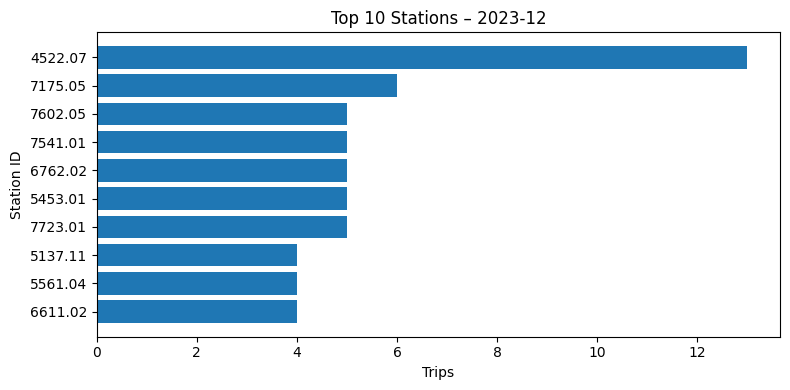

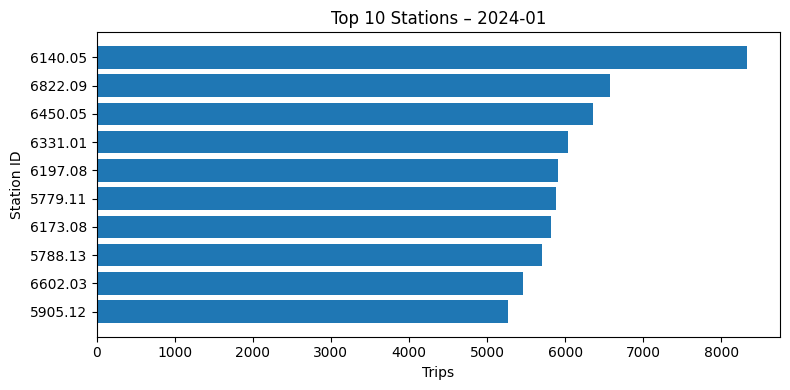

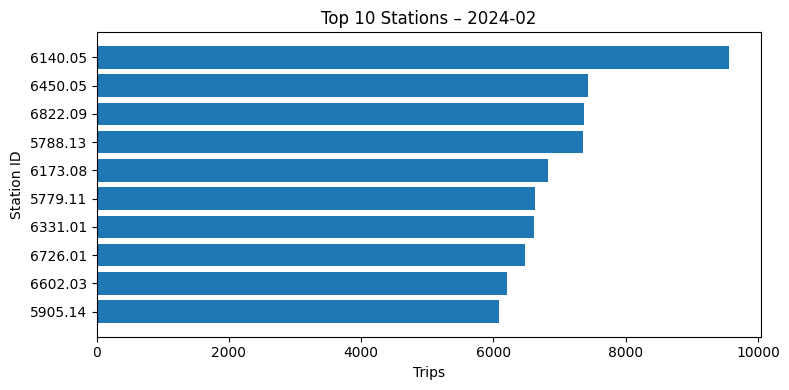

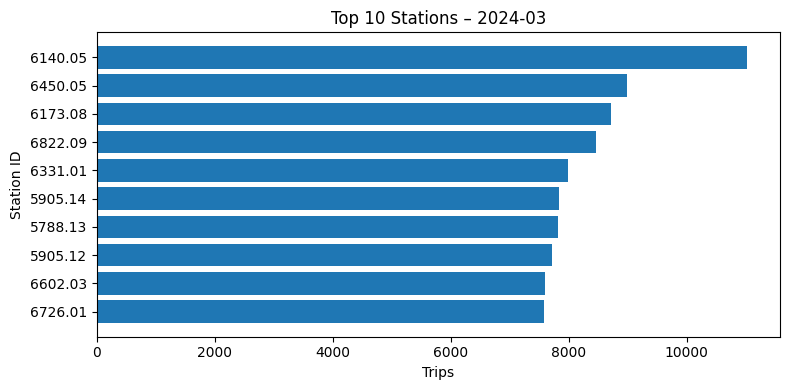

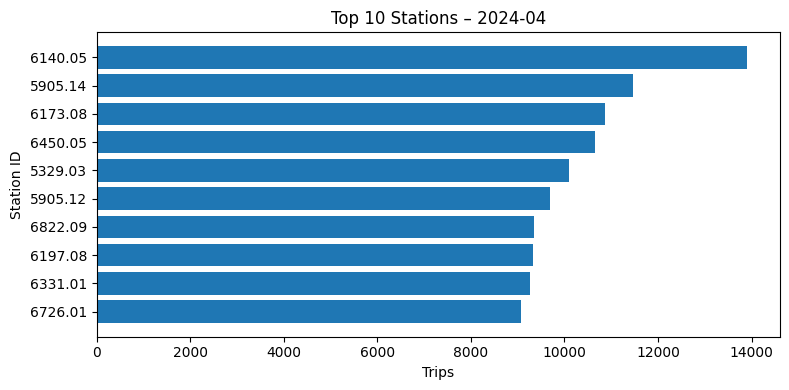

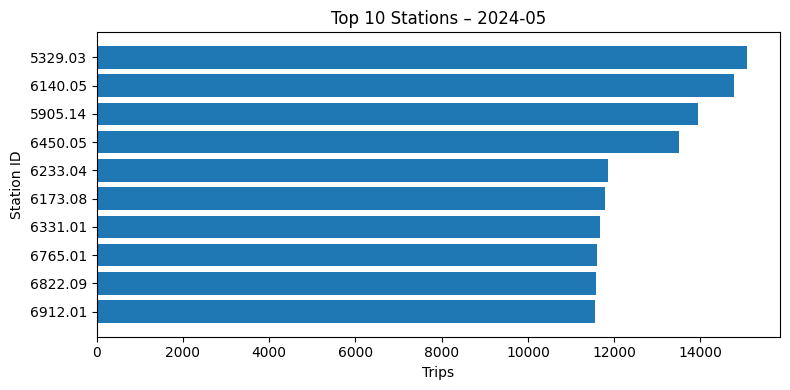

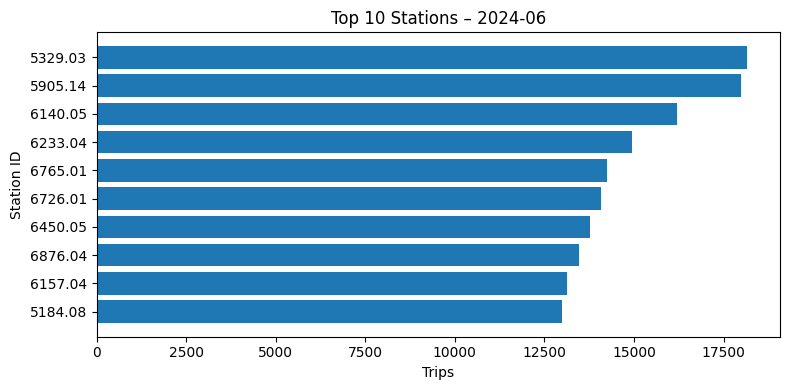

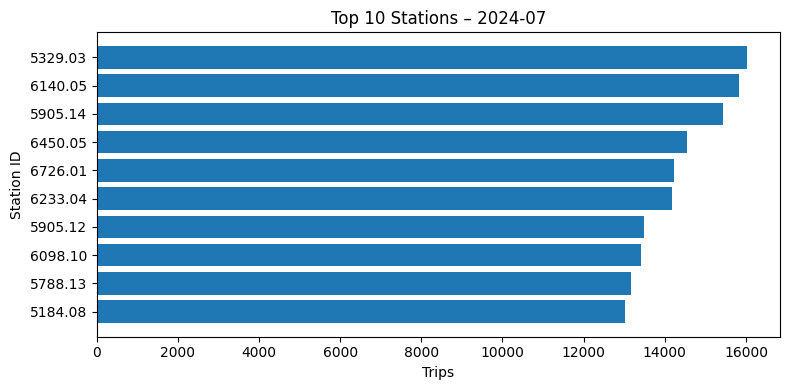

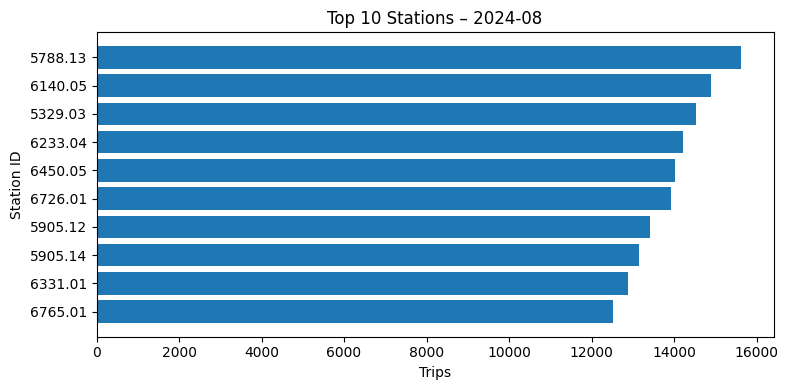

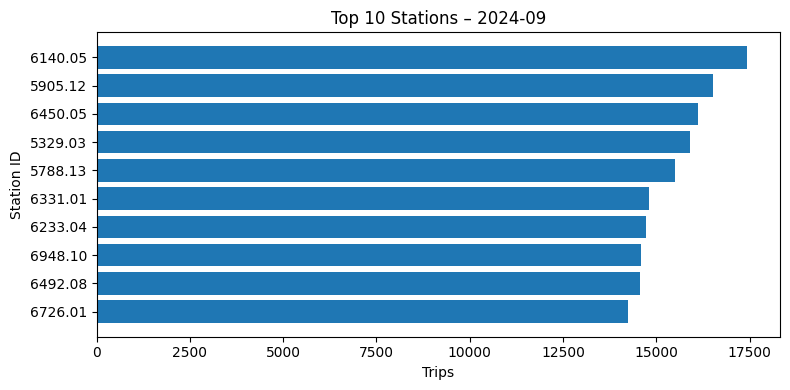

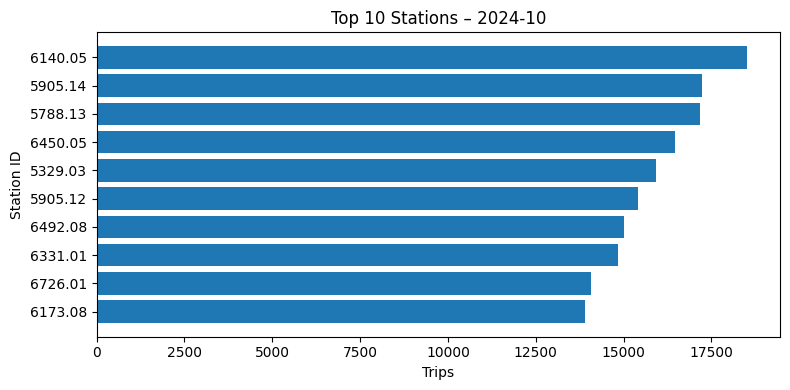

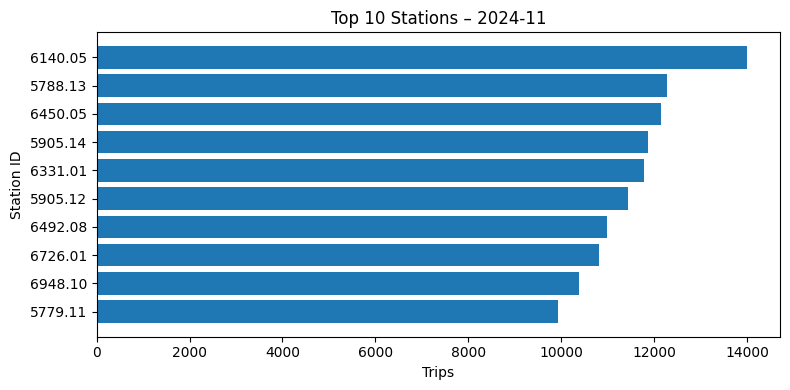

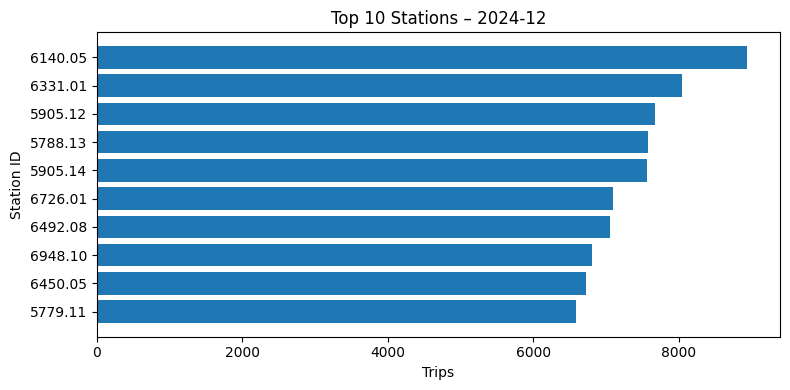

In [61]:
df = kpi2_station_demand_monthly.copy()

import matplotlib.pyplot as plt

months = df["month"].unique()

for m in months:
    temp = df[df["month"] == m]

    plt.figure(figsize=(8,4))
    plt.barh(temp["station_id"].astype(str), temp["trips"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Stations – {m}")
    plt.xlabel("Trips")
    plt.ylabel("Station ID")
    plt.tight_layout()
    plt.show()


## KPI 3

#### Station Imbalance Index (Monthly)

In [63]:
kpi3_station_imbalance = con.execute("""
WITH start_counts AS (
    SELECT
        strftime('%Y-%m', started_at) AS month,
        start_station_id AS station_id,
        COUNT(*) AS outflow
    FROM citibike_typed
    GROUP BY month, start_station_id
),
end_counts AS (
    SELECT
        strftime('%Y-%m', started_at) AS month,
        end_station_id AS station_id,
        COUNT(*) AS inflow
    FROM citibike_typed
    GROUP BY month, end_station_id
)
SELECT
    COALESCE(s.month, e.month) AS month,
    COALESCE(s.station_id, e.station_id) AS station_id,
    COALESCE(inflow, 0) AS inflow,
    COALESCE(outflow, 0) AS outflow,
    COALESCE(inflow, 0) - COALESCE(outflow, 0) AS imbalance_index
FROM start_counts s
FULL OUTER JOIN end_counts e
ON s.month = e.month AND s.station_id = e.station_id
ORDER BY month, ABS(imbalance_index) DESC
""").fetchdf()

kpi3_station_imbalance


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,station_id,inflow,outflow,imbalance_index
0,2023-12,None,46,0,46
1,2023-12,5696.03,11,0,11
2,2023-12,4522.07,5,13,-8
3,2023-12,4903.09,8,0,8
4,2023-12,7304.08,7,0,7
...,...,...,...,...,...
27784,2024-12,6056.02,89,89,0
27785,2024-12,8216.02,98,98,0
27786,2024-12,4517.03,531,531,0
27787,2024-12,8676.01,5,5,0


#### Imbalance Category Column

In [67]:
kpi3_station_imbalance_classified = con.execute("""
WITH start_counts AS (
    SELECT
        strftime('%Y-%m', started_at) AS month,
        start_station_id AS station_id,
        COUNT(*) AS outflow
    FROM citibike_typed
    WHERE start_station_id IS NOT NULL
    GROUP BY month, start_station_id
),
end_counts AS (
    SELECT
        strftime('%Y-%m', started_at) AS month,
        end_station_id AS station_id,
        COUNT(*) AS inflow
    FROM citibike_typed
    WHERE end_station_id IS NOT NULL
    GROUP BY month, end_station_id
),
imbalance AS (
    SELECT
        COALESCE(s.month, e.month) AS month,
        COALESCE(s.station_id, e.station_id) AS station_id,
        COALESCE(inflow, 0) AS inflow,
        COALESCE(outflow, 0) AS outflow,
        COALESCE(inflow, 0) - COALESCE(outflow, 0) AS imbalance_index
    FROM start_counts s
    FULL OUTER JOIN end_counts e
        ON s.month = e.month AND s.station_id = e.station_id
)
SELECT
    month,
    station_id,
    inflow,
    outflow,
    imbalance_index,
    CASE
        WHEN imbalance_index > 20 THEN 'Severe overflow'
        WHEN imbalance_index BETWEEN 5 AND 20 THEN 'Mild overflow'
        WHEN imbalance_index BETWEEN -5 AND 5 THEN 'Balanced'
        WHEN imbalance_index BETWEEN -20 AND -5 THEN 'Mild shortage'
        ELSE 'Severe shortage'
    END AS imbalance_category
FROM imbalance
ORDER BY month, ABS(imbalance_index) DESC
""").fetchdf()

kpi3_station_imbalance_classified


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,station_id,inflow,outflow,imbalance_index,imbalance_category
0,2023-12,5696.03,11,0,11,Mild overflow
1,2023-12,4522.07,5,13,-8,Mild shortage
2,2023-12,4903.09,8,0,8,Mild overflow
3,2023-12,7304.08,7,0,7,Mild overflow
4,2023-12,6876.04,8,2,6,Mild overflow
...,...,...,...,...,...,...
27759,2024-12,6423.03,108,108,0,Balanced
27760,2024-12,5051.01,996,996,0,Balanced
27761,2024-12,8268.08,81,81,0,Balanced
27762,2024-12,6304.04,148,148,0,Balanced


In [70]:
summary_imbalance = con.execute("""
SELECT
    month,
    imbalance_category,
    COUNT(*) AS station_count
FROM kpi3_station_imbalance_classified
GROUP BY month, imbalance_category
ORDER BY month, imbalance_category
""").fetchdf()

summary_imbalance


,month,imbalance_category,station_count
0,2023-12,Balanced,400
1,2023-12,Mild overflow,7
2,2023-12,Mild shortage,2
3,2024-01,Balanced,665
4,2024-01,Mild overflow,584
...,...,...,...
58,2024-12,Balanced,613
59,2024-12,Mild overflow,529
60,2024-12,Mild shortage,382
61,2024-12,Severe overflow,336


In [71]:
pivot_imbalance = summary_imbalance.pivot(
    index="month",
    columns="imbalance_category",
    values="station_count"
).fillna(0)

pivot_imbalance


imbalance_category,Balanced,Mild overflow,Mild shortage,Severe overflow,Severe shortage
month,,,,,
2023-12,400.0,7.0,2.0,0.0,0.0
2024-01,665.0,584.0,262.0,341.0,410.0
2024-02,741.0,553.0,305.0,351.0,316.0
2024-03,648.0,560.0,300.0,374.0,392.0
2024-04,608.0,596.0,290.0,384.0,391.0
2024-05,573.0,594.0,332.0,386.0,397.0
2024-06,618.0,568.0,348.0,365.0,411.0
2024-07,517.0,635.0,329.0,403.0,405.0
2024-08,550.0,512.0,349.0,403.0,475.0


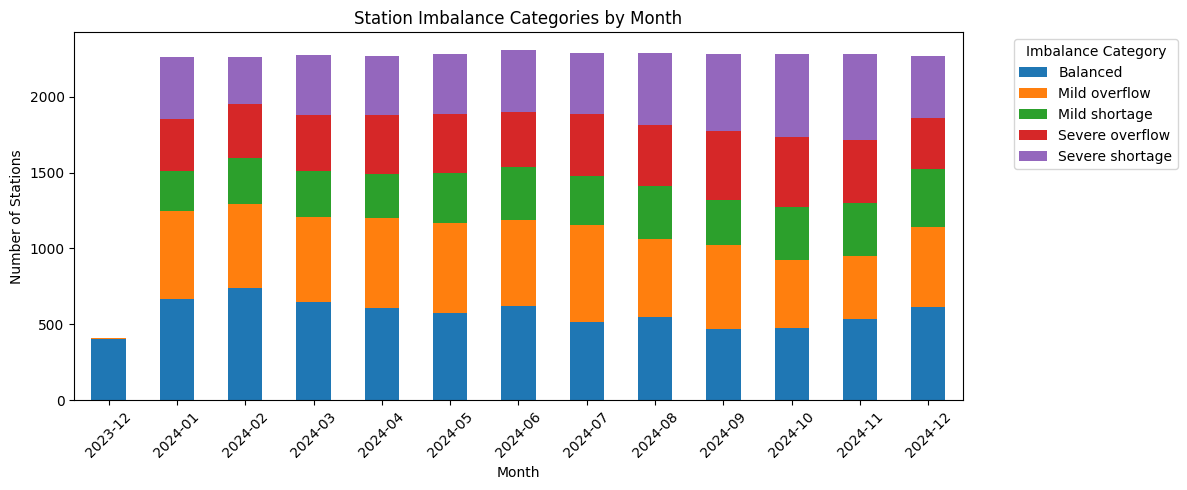

In [72]:
import matplotlib.pyplot as plt

pivot_imbalance.plot(
    kind="bar",
    stacked=True,
    figsize=(12,5)
)

plt.title("Station Imbalance Categories by Month")
plt.xlabel("Month")
plt.ylabel("Number of Stations")
plt.xticks(rotation=45)
plt.legend(title="Imbalance Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


## KPI 4 -Weather Impact Score

#### 4A — Rain Impact

In [64]:
kpi4_rain_impact = con.execute("""
SELECT
    CASE 
        WHEN prcp > 0 THEN 'Rainy Day'
        ELSE 'No Rain'
    END AS weather_type,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY weather_type
""").fetchdf()

kpi4_rain_impact


,weather_type,trips
0,No Rain,29824925
1,Rainy Day,14478284


#### 4B — Temperature Impact (°C Buckets)

In [65]:
kpi4_temp_impact = con.execute("""
SELECT
    CASE
        WHEN (temp - 32) * 5.0 / 9.0 < 0 THEN 'Below 0°C'
        WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 0 AND 10 THEN '0–10°C'
        WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 10 AND 20 THEN '10–20°C'
        WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 20 AND 30 THEN '20–30°C'
        ELSE 'Above 30°C'
    END AS temp_bucket,
    COUNT(*) AS trips
FROM citibike_typed
WHERE temp IS NOT NULL
GROUP BY temp_bucket
ORDER BY temp_bucket
""").fetchdf()

kpi4_temp_impact


,temp_bucket,trips
0,0–10°C,7945732
1,10–20°C,16264230
2,20–30°C,18942075
3,Above 30°C,159020
4,Below 0°C,991742


#### 4C — Weather Impact Score (Normalized)

In [66]:
kpi4_weather_score = con.execute("""
SELECT
    ROUND(
        AVG(
            CASE 
                WHEN prcp > 0 THEN -1
                WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 15 AND 25 THEN 1
                ELSE 0
            END
        ),
        2
    ) AS weather_impact_score
FROM citibike_typed
""").fetchdf()

kpi4_weather_score


,weather_impact_score
0,0.02
